In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

print("Forecasting Notebook Ready")

Forecasting Notebook Ready


In [2]:
df = pd.read_csv("../data/processed/economic_data.csv")

df["DATE"] = pd.to_datetime(df["DATE"])

# Keep only Date and CPI
df = df[["DATE", "CPI"]]

df.head()

,DATE,CPI
0,1854-12-01,21.48
1,1855-01-01,21.48
2,1855-02-01,21.48
3,1855-03-01,21.48
4,1855-04-01,21.48


In [3]:
forecast_df = df.copy()

# Lag features
forecast_df["Lag_1"] = forecast_df["CPI"].shift(1)
forecast_df["Lag_3"] = forecast_df["CPI"].shift(3)
forecast_df["Lag_6"] = forecast_df["CPI"].shift(6)

# Rolling averages
forecast_df["Rolling_Mean_3"] = (
    forecast_df["CPI"].rolling(3).mean()
)

forecast_df["Rolling_Mean_6"] = (
    forecast_df["CPI"].rolling(6).mean()
)

# Future CPI (1 month ahead)
forecast_df["Target"] = forecast_df["CPI"].shift(-1)

forecast_df = forecast_df.dropna()

forecast_df.head()


,DATE,CPI,Lag_1,Lag_3,Lag_6,Rolling_Mean_3,Rolling_Mean_6,Target
6,1855-06-01,21.48,21.48,21.48,21.48,21.48,21.48,21.48
7,1855-07-01,21.48,21.48,21.48,21.48,21.48,21.48,21.48
8,1855-08-01,21.48,21.48,21.48,21.48,21.48,21.48,21.48
9,1855-09-01,21.48,21.48,21.48,21.48,21.48,21.48,21.48
10,1855-10-01,21.48,21.48,21.48,21.48,21.48,21.48,21.48


In [6]:
features = [
    "Lag_1",
    "Lag_3",
    "Lag_6",
    "Rolling_Mean_3",
    "Rolling_Mean_6"
]

X = forecast_df[features]
y = forecast_df["Target"]

print(X.shape)
print(y.shape)

(2054, 5)
(2054,)


In [5]:
split = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (1643, 5)
Test : (411, 5)


In [7]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [8]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [9]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "MAPE": [
        mean_absolute_percentage_error(y_test, linear_pred) * 100,
        mean_absolute_percentage_error(y_test, rf_pred) * 100
    ]
})

results.round(3)

,Model,MAE,RMSE,MAPE
0,Linear Regression,0.496,0.717,0.222
1,Random Forest,78.496,93.752,32.445


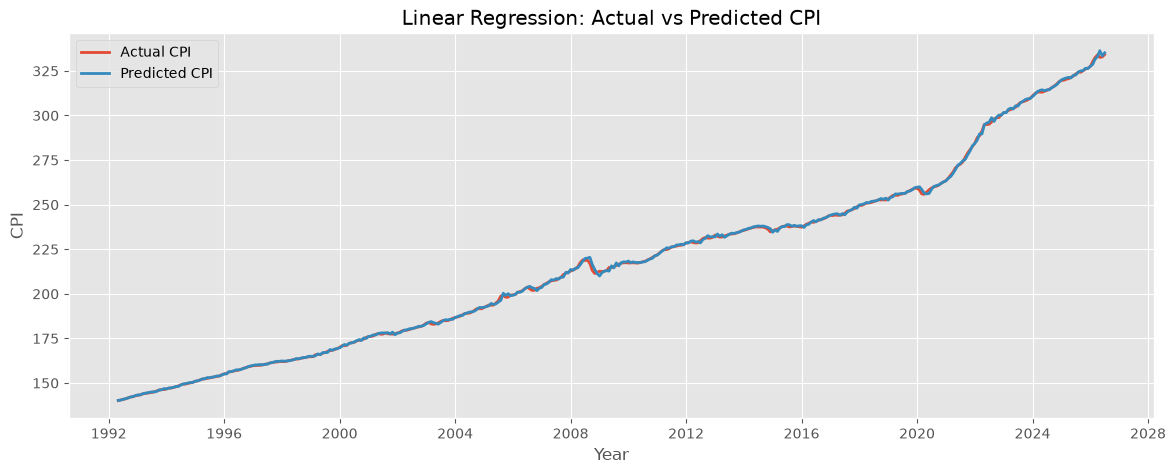

In [10]:
plt.figure(figsize=(14,5))

plt.plot(
    forecast_df["DATE"].iloc[split:],
    y_test,
    label="Actual CPI",
    linewidth=2
)

plt.plot(
    forecast_df["DATE"].iloc[split:],
    linear_pred,
    label="Predicted CPI",
    linewidth=2
)

plt.title("Linear Regression: Actual vs Predicted CPI")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.legend()

plt.show()

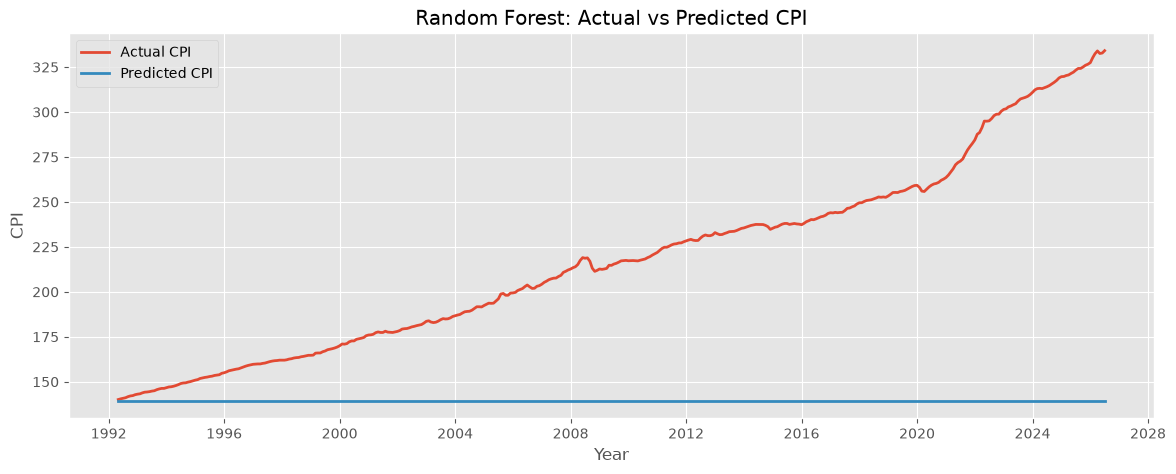

In [11]:
plt.figure(figsize=(14,5))

plt.plot(
    forecast_df["DATE"].iloc[split:],
    y_test,
    label="Actual CPI",
    linewidth=2
)

plt.plot(
    forecast_df["DATE"].iloc[split:],
    rf_pred,
    label="Predicted CPI",
    linewidth=2
)

plt.title("Random Forest: Actual vs Predicted CPI")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.legend()

plt.show()

In [13]:
import joblib
from pathlib import Path

model_path = Path("../models")
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(linear_model, model_path / "forecasting_model.pkl")

print("Best forecasting model (Linear Regression) saved!")

Best forecasting model (Linear Regression) saved!
